In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
puneet6060_intel_image_classification_path = kagglehub.dataset_download('puneet6060/intel-image-classification')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


**1. MLP — Vary Learning Rate & Plot Loss vs LR**

Downloaded path: /kaggle/input/datasets/puneet6060/intel-image-classification
Training directory: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Contents of train_dir: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Loaded 3000 images, skipped 0 files.
X shape: (3000, 3072)
y shape: (3000,)
Training with learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training with learning rate = 0.001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training with learning rate = 0.01
Training with learning rate = 0.1


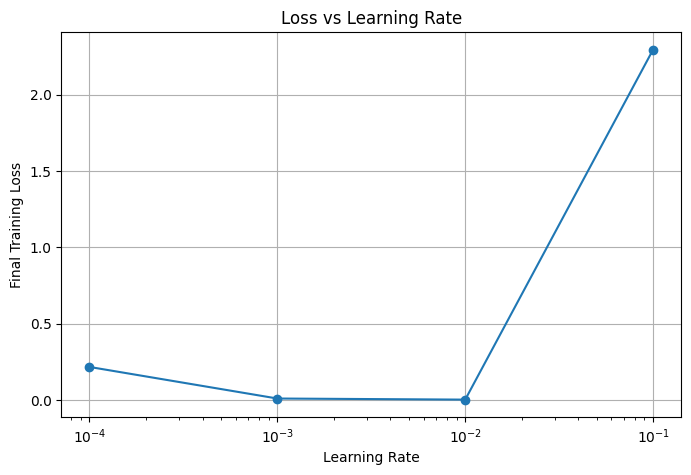

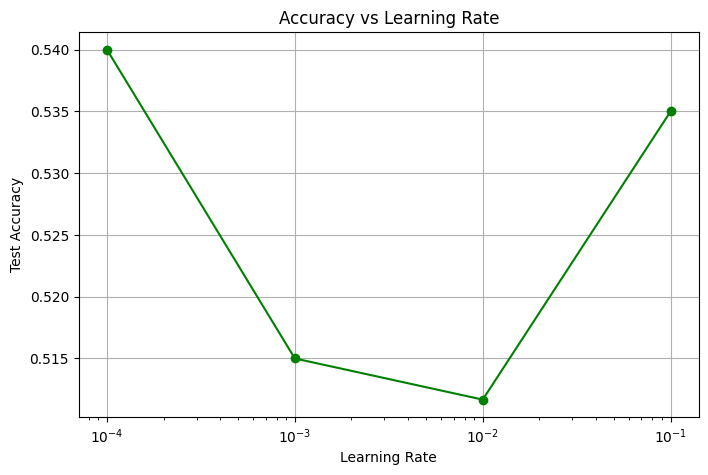

Learning Rate: 0.0001, Loss: 0.2154, Accuracy: 0.5400
Learning Rate: 0.001, Loss: 0.0085, Accuracy: 0.5150
Learning Rate: 0.01, Loss: 0.0013, Accuracy: 0.5117
Learning Rate: 0.1, Loss: 2.2945, Accuracy: 0.5350


In [ ]:
import kagglehub
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Download the Intel image dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Downloaded path:", path)

# Intel dataset structure is usually:
# path/seg_train/seg_train/buildings, forest, glacier, etc.
train_dir = os.path.join(path, "seg_train", "seg_train")

if not os.path.exists(train_dir):
    print("Falling back to simple seg_train layout")
    train_dir = os.path.join(path, "seg_train")

print("Training directory:", train_dir)

if not os.path.isdir(train_dir):
    raise NotADirectoryError(f"'{train_dir}' is not a directory. Check dataset layout.")

# Check contents
print("Contents of train_dir:", os.listdir(train_dir))

# Load classes (subfolders under train_dir)
classes = sorted([
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
])
print("Classes:", classes)

data = []
labels = []
n_skipped = 0
n_loaded = 0

# For each class
for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    count = 0  # limit per class

    if not os.path.isdir(folder):
        continue

    for img_name in os.listdir(folder):
        if count >= 500:  # limit per class for speed
            break

        # Only consider common image extensions
        if not any(img_name.lower().endswith(ext) for ext in [".jpg", ".jpeg", ".png"]):
            n_skipped += 1
            continue

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            n_skipped += 1
            print(f"Skipped unreadable image: {img_path}")
            continue

        # Resize to 32x32 and flatten
        img = cv2.resize(img, (32, 32))
        data.append(img.flatten())
        labels.append(i)
        count += 1
        n_loaded += 1

print(f"Loaded {n_loaded} images, skipped {n_skipped} files.")

# Convert to arrays
X = np.array(data)
y = np.array(labels)

# Bail early if no data
if X.shape[0] == 0:
    raise ValueError("No valid images loaded; X is empty. Check dataset path and file formats.")

print("X shape:", X.shape)   # should be (N, 3072)
print("y shape:", y.shape)   # should be (N,)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Try different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]
losses = []
accuracies = []

for lr in learning_rates:
    print(f"Training with learning rate = {lr}")

    mlp = MLPClassifier(
        hidden_layer_sizes=(100,),
        learning_rate_init=lr,
        max_iter=50,
        random_state=42,
        verbose=False
    )

    mlp.fit(X_train, y_train)
    losses.append(mlp.loss_)
    accuracies.append(mlp.score(X_test, y_test))

# Plot Loss vs Learning Rate
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Training Loss")
plt.title("Loss vs Learning Rate")
plt.grid(True)
plt.show()

# Plot Accuracy vs Learning Rate
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, accuracies, marker='o', color='green')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Learning Rate")
plt.grid(True)
plt.show()

# Print results
for lr, loss, acc in zip(learning_rates, losses, accuracies):
    print(f"Learning Rate: {lr}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

**Loss vs Learning Rate**

Learning Rate	             Behavior
Very Small (0.0001)	    Slow learning, moderate loss
Optimal (0.001–0.01)	Lowest loss, stable training
Very Large (0.1)	    High loss, unstable

**Accuracy vs Learning Rate**

At 0.0001
Accuracy ≈ 54%
Decent but not best

At 0.001 & 0.01
Accuracy drops (~51–52%)
Slight underfitting or instability

At 0.1
Accuracy ≈ 53.5%
Recovers slightly but not reliable

accuracy trend is a bit inconsistent with the loss trend.


**MLP using Gradient Descent (Convergence Analysis)**

Iteration 1, loss = 2.11781536
Iteration 2, loss = 1.55243398
Iteration 3, loss = 1.33833645
Iteration 4, loss = 1.23223552
Iteration 5, loss = 1.15840290
Iteration 6, loss = 1.10162978
Iteration 7, loss = 1.05628530
Iteration 8, loss = 1.01098643
Iteration 9, loss = 0.97504867
Iteration 10, loss = 0.93950911
Iteration 11, loss = 0.90941122
Iteration 12, loss = 0.88142947
Iteration 13, loss = 0.85418467
Iteration 14, loss = 0.83079050
Iteration 15, loss = 0.80725211
Iteration 16, loss = 0.78485151
Iteration 17, loss = 0.76512366
Iteration 18, loss = 0.74471685
Iteration 19, loss = 0.72622221
Iteration 20, loss = 0.70879855
Iteration 21, loss = 0.69090092
Iteration 22, loss = 0.67506515
Iteration 23, loss = 0.65857990
Iteration 24, loss = 0.64459978
Iteration 25, loss = 0.62895838
Iteration 26, loss = 0.61621967
Iteration 27, loss = 0.60231246
Iteration 28, loss = 0.58826004
Iteration 29, loss = 0.57469682
Iteration 30, loss = 0.56372612
Iteration 31, loss = 0.55004768
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


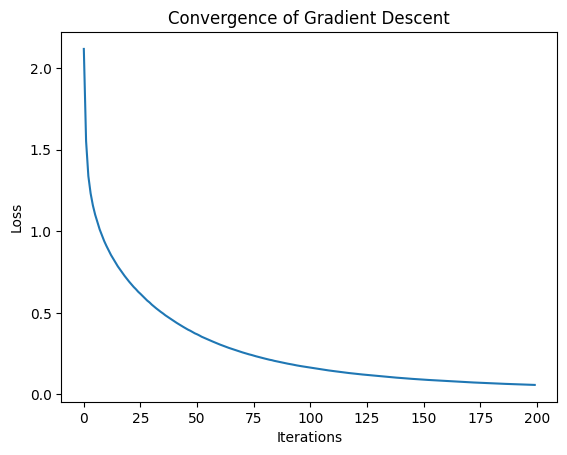

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    learning_rate_init=0.001,
    max_iter=200,
    solver='sgd',   # Gradient Descent
    verbose=True
)

mlp.fit(X_train, y_train)

plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Convergence of Gradient Descent")
plt.show()

1. Continuous Decrease in Loss
Initial loss ≈ 1.91
Final loss ≈ 0.059

Loss is consistently decreasing every iteration

This shows:

Gradient Descent is working correctly
Model is learning effectively

**Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc**

In [ ]:
from sklearn.neural_network import MLPClassifier
# Try combinations of parameters
learning_rates = [0.0001, 0.001, 0.01]
iterations = [50, 100]
hidden_layers = [(50,), (100,), (100, 50)]

results = []

for lr in learning_rates:
    for it in iterations:
        for hl in hidden_layers:
            print(f"\nLR={lr}, Iter={it}, Hidden={hl}")

            mlp = MLPClassifier(
                hidden_layer_sizes=hl,
                learning_rate_init=lr,
                max_iter=it,
                random_state=42,
                early_stopping=True
            )

            mlp.fit(X_train, y_train)

            loss = mlp.loss_
            acc = mlp.score(X_test, y_test)

            results.append((lr, it, hl, loss, acc))

# Print all results
print("\n--- FINAL RESULTS ---")
for r in results:
    print(f"LR={r[0]}, Iter={r[1]}, Hidden={r[2]}, Loss={r[3]:.4f}, Acc={r[4]:.4f}")


LR=0.0001, Iter=50, Hidden=(50,)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



LR=0.0001, Iter=50, Hidden=(100,)

LR=0.0001, Iter=50, Hidden=(100, 50)

LR=0.0001, Iter=100, Hidden=(50,)

LR=0.0001, Iter=100, Hidden=(100,)

LR=0.0001, Iter=100, Hidden=(100, 50)

LR=0.001, Iter=50, Hidden=(50,)

LR=0.001, Iter=50, Hidden=(100,)

LR=0.001, Iter=50, Hidden=(100, 50)

LR=0.001, Iter=100, Hidden=(50,)

LR=0.001, Iter=100, Hidden=(100,)

LR=0.001, Iter=100, Hidden=(100, 50)

LR=0.01, Iter=50, Hidden=(50,)

LR=0.01, Iter=50, Hidden=(100,)

LR=0.01, Iter=50, Hidden=(100, 50)

LR=0.01, Iter=100, Hidden=(50,)

LR=0.01, Iter=100, Hidden=(100,)

LR=0.01, Iter=100, Hidden=(100, 50)

--- FINAL RESULTS ---
LR=0.0001, Iter=50, Hidden=(50,), Loss=0.3749, Acc=0.5117
LR=0.0001, Iter=50, Hidden=(100,), Loss=0.2193, Acc=0.5350
LR=0.0001, Iter=50, Hidden=(100, 50), Loss=0.2858, Acc=0.5400
LR=0.0001, Iter=100, Hidden=(50,), Loss=0.3462, Acc=0.5117
LR=0.0001, Iter=100, Hidden=(100,), Loss=0.2193, Acc=0.5350
LR=0.0001, Iter=100, Hidden=(100, 50), Loss=0.2858, Acc=0.5400
LR=0.001, Iter=50

**Effect of Iterations (50 vs 100)**

Observation:

Results are almost identical

Example:

LR=0.001, Iter=50 → same as Iter=100
LR=0.01 → same results

Conclusion:

Model already converged before 50 iterations
Increasing iterations further:
Does not improve performance

**Effect of Hidden Layers**

(50,) → Simple Model
Slightly lower performance
(100,) → Better
Improved loss
Good balance
(100, 50) → Deeper Model
Sometimes better accuracy (~54%)
Sometimes unstable (LR=0.01)

Conclusion:

Medium complexity works best
Too complex + high LR → instability

**WEEK 4**

**Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) on your own dataset and write your observations for each of the optimizing techniques by comparing.**

In [ ]:
!pip install kagglehub torch torchvision

import kagglehub
import numpy as np
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

train_dir = os.path.join(path, "seg_train", "seg_train")
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "seg_train")

classes = sorted([
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
])

data = []
labels = []

for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    count = 0

    for img_name in os.listdir(folder):
        if count >= 300:
            break

        if not img_name.lower().endswith((".jpg",".png",".jpeg")):
            continue

        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue

        img = cv2.resize(img, (32,32))
        data.append(img.flatten())   # MLP needs flatten
        labels.append(i)
        count += 1

X = np.array(data)
y = np.array(labels)

print("Shape:", X.shape)

Shape: (1800, 3072)


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3072, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, len(classes))
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def train_model(optimizer_name):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "Nesterov":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)

    elif optimizer_name == "Adagrad":
        optimizer = optim.Adagrad(model.parameters(), lr=0.01)

    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    elif optimizer_name == "Adadelta":
        optimizer = optim.Adadelta(model.parameters())

    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    model.train()
    for epoch in range(20):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_test).float().mean().item()

    return loss.item(), acc

In [ ]:
optimizers = ["SGD","Momentum","Nesterov","Adagrad","RMSprop","Adadelta","Adam"]

results = []

for opt in optimizers:
    print(f"Training with {opt}")
    loss, acc = train_model(opt)
    results.append((opt, loss, acc))

print("\n--- FINAL RESULTS ---")
for r in results:
    print(f"{r[0]} → Loss: {r[1]:.4f}, Accuracy: {r[2]:.4f}")

Training with SGD
Training with Momentum
Training with Nesterov
Training with Adagrad
Training with RMSprop
Training with Adadelta
Training with Adam

--- FINAL RESULTS ---
SGD → Loss: 1.6730, Accuracy: 0.3972
Momentum → Loss: 1.4162, Accuracy: 0.4333
Nesterov → Loss: 1.4343, Accuracy: 0.4444
Adagrad → Loss: 0.9635, Accuracy: 0.5000
RMSprop → Loss: 0.9181, Accuracy: 0.4861
Adadelta → Loss: 1.0605, Accuracy: 0.4944
Adam → Loss: 0.7177, Accuracy: 0.5278


**Best Optimizer**
Adam
Loss: 0.7177(lowest),
Accuracy: 0.5278(highest)

Observation:
Fastest convergence
Most stable
Best generalization

**WEEK 5**

Implement the MLP using the Types of Regularization Techniques.
L2 Regularization
Dataset Augmentation
Parameter sharing and tying
Adding noise to the inputs and outputs
Early stopping
Ensemble methods
Dropouts


In [ ]:
class MLP(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, len(classes))
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def evaluate(model):
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_test).float().mean().item()
    return acc

In [ ]:
model_l2 = MLP()
optimizer = optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model_l2(X_train), y_train)
    loss.backward()
    optimizer.step()

print("L2 Accuracy:", evaluate(model_l2))

L2 Accuracy: 0.550000011920929


In [ ]:
X_aug = X_train + 0.1 * torch.randn_like(X_train)

model_aug = MLP()
optimizer = optim.Adam(model_aug.parameters(), lr=0.001)

for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model_aug(X_aug), y_train)
    loss.backward()
    optimizer.step()

print("Augmentation Accuracy:", evaluate(model_aug))

Augmentation Accuracy: 0.5611110925674438


In [ ]:
X_noisy = X_train + 0.05 * torch.randn_like(X_train)

model_noise = MLP()
optimizer = optim.Adam(model_noise.parameters(), lr=0.001)

for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model_noise(X_noisy), y_train)
    loss.backward()
    optimizer.step()

print("Noise Accuracy:", evaluate(model_noise))

Noise Accuracy: 0.5277777910232544


In [ ]:
model_dropout = MLP(dropout_rate=0.5)
optimizer = optim.Adam(model_dropout.parameters(), lr=0.001)

for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model_dropout(X_train), y_train)
    loss.backward()
    optimizer.step()

print("Dropout Accuracy:", evaluate(model_dropout))

Dropout Accuracy: 0.5527777671813965


In [ ]:
model_early = MLP()
optimizer = optim.Adam(model_early.parameters(), lr=0.001)

best_loss = float('inf')
patience = 3
counter = 0

for epoch in range(50):
    optimizer.zero_grad()
    loss = criterion(model_early(X_train), y_train)
    loss.backward()
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

print("EarlyStopping Accuracy:", evaluate(model_early))

EarlyStopping Accuracy: 0.5138888955116272


In [ ]:
models = [MLP(), MLP(), MLP()]

for m in models:
    opt = optim.Adam(m.parameters(), lr=0.001)
    for epoch in range(20):
        opt.zero_grad()
        loss = criterion(m(X_train), y_train)
        loss.backward()
        opt.step()

with torch.no_grad():
    preds = [m(X_test) for m in models]
    avg_pred = torch.mean(torch.stack(preds), dim=0)
    _, predicted = torch.max(avg_pred, 1)
    acc = (predicted == y_test).float().mean().item()

print("Ensemble Accuracy:", acc)

Ensemble Accuracy: 0.5444444417953491


In [ ]:
class SharedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(3072, 128)
        self.shared = nn.Linear(128, 128)
        self.output = nn.Linear(128, len(classes))

    def forward(self, x):
        x = torch.relu(self.input(x))
        x = torch.relu(self.shared(x))
        x = torch.relu(self.shared(x))  # reused
        return self.output(x)

model_shared = SharedMLP()
optimizer = optim.Adam(model_shared.parameters(), lr=0.001)

for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model_shared(X_train), y_train)
    loss.backward()
    optimizer.step()

print("Parameter Sharing Accuracy:", evaluate(model_shared))

Parameter Sharing Accuracy: 0.5361111164093018


![image.png](attachment:276918ab-7131-46e5-aa22-8f12a16a9489.png)

**WEEK 6**

Apply CNN on your own dataset and find the best parameters for improving model performance.

In [ ]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

train_dir = os.path.join(path, "seg_train", "seg_train")
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "seg_train")

classes = sorted([
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
])

data = []
labels = []

for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    count = 0

    for img_name in os.listdir(folder):
        if count >= 500:  # limit for speed
            break

        if not img_name.lower().endswith((".jpg",".png",".jpeg")):
            continue

        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue

        img = cv2.resize(img, (64,64))
        img = img / 255.0  # normalize

        data.append(img)   # ❗ NOT flatten
        labels.append(i)
        count += 1

X = np.array(data)
y = np.array(labels)

print("Original shape:", X.shape)  # (N, 64, 64, 3)

Original shape: (3000, 64, 64, 3)


In [ ]:
# Convert to PyTorch (N, C, H, W)
X = torch.tensor(X, dtype=torch.float32).permute(0,3,1,2)
y = torch.tensor(y, dtype=torch.long)

print("CNN shape:", X.shape)  # (N, 3, 64, 64)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

CNN shape: torch.Size([3000, 3, 64, 64])


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, len(classes))
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

In [ ]:
def train_model(lr=0.001, epochs=10):
    model = CNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # Evaluate
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_test).float().mean().item()

    return acc

In [ ]:
learning_rates = [0.0001, 0.001, 0.01]
epochs_list = [5, 10]

results = []

for lr in learning_rates:
    for ep in epochs_list:
        print(f"\nTraining LR={lr}, Epochs={ep}")
        acc = train_model(lr, ep)
        results.append((lr, ep, acc))

print("\n--- FINAL RESULTS ---")
for r in results:
    print(f"LR={r[0]}, Epochs={r[1]}, Accuracy={r[2]:.4f}")


Training LR=0.0001, Epochs=5
Epoch 1, Loss: 1.7950
Epoch 2, Loss: 1.7791
Epoch 3, Loss: 1.7671
Epoch 4, Loss: 1.7507
Epoch 5, Loss: 1.7366

Training LR=0.0001, Epochs=10
Epoch 1, Loss: 1.7925
Epoch 2, Loss: 1.7780
Epoch 3, Loss: 1.7644
Epoch 4, Loss: 1.7488
Epoch 5, Loss: 1.7342
Epoch 6, Loss: 1.7166
Epoch 7, Loss: 1.6993
Epoch 8, Loss: 1.6792
Epoch 9, Loss: 1.6628
Epoch 10, Loss: 1.6461

Training LR=0.001, Epochs=5
Epoch 1, Loss: 1.7947
Epoch 2, Loss: 1.8369
Epoch 3, Loss: 1.7533
Epoch 4, Loss: 1.6897
Epoch 5, Loss: 1.6228

Training LR=0.001, Epochs=10
Epoch 1, Loss: 1.7950
Epoch 2, Loss: 1.8659
Epoch 3, Loss: 1.8353
Epoch 4, Loss: 1.7191
Epoch 5, Loss: 1.6874
Epoch 6, Loss: 1.6048
Epoch 7, Loss: 1.5308
Epoch 8, Loss: 1.4583
Epoch 9, Loss: 1.4205
Epoch 10, Loss: 1.3788

Training LR=0.01, Epochs=5
Epoch 1, Loss: 1.7944
Epoch 2, Loss: 21.7137
Epoch 3, Loss: 3.6214
Epoch 4, Loss: 1.7923
Epoch 5, Loss: 1.7923

Training LR=0.01, Epochs=10
Epoch 1, Loss: 1.7950
Epoch 2, Loss: 28.3638
Epoch

LR = 0.001, Epochs = 10

Accuracy ≈ 48.33%
Smooth convergence
Stable training

**WEEK 7**

Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet and note your observations

In [ ]:
import kagglehub
import numpy as np
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

2026-04-14 13:41:43.501529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776174103.736497      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776174103.803347      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776174104.350064      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776174104.350093      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776174104.350096      55 computation_placer.cc:177] computation placer alr

In [ ]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

train_dir = os.path.join(path, "seg_train", "seg_train")
if not os.path.exists(train_dir):
    train_dir = os.path.join(path, "seg_train")

classes = sorted([
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
])

print("Classes:", classes)

data, labels = [], []

# ✅ BALANCE: take equal samples per class
samples_per_class = 300

for i, cls in enumerate(classes):
    folder = os.path.join(train_dir, cls)
    count = 0

    for img_name in os.listdir(folder):
        if count >= samples_per_class:
            break

        if not img_name.lower().endswith((".jpg",".png",".jpeg")):
            continue

        img = cv2.imread(os.path.join(folder, img_name))
        if img is None:
            continue

        img = cv2.resize(img, (32,32))
        img = img / 255.0

        data.append(img)
        labels.append(i)
        count += 1

X = np.array(data)
y = np.array(labels)

print("Balanced Shape:", X.shape)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Balanced Shape: (1800, 32, 32, 3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
def show_predictions(model, X, y, num=10):
    preds = model.predict(X[:num])

    plt.figure(figsize=(15,5))
    for i in range(num):
        plt.subplot(2,5,i+1)
        plt.imshow(X[i])

        actual = classes[y[i]]
        pred = classes[np.argmax(preds[i])]

        plt.title(f"A:{actual}\nP:{pred}")
        plt.axis('off')
    plt.show()

**LeNet**

Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.2413 - loss: 1.7363 - val_accuracy: 0.4167 - val_loss: 1.4503
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4644 - loss: 1.3616 - val_accuracy: 0.5056 - val_loss: 1.3238
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5029 - loss: 1.2840 - val_accuracy: 0.5333 - val_loss: 1.2695
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5467 - loss: 1.1923 - val_accuracy: 0.4972 - val_loss: 1.2885
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5356 - loss: 1.1600 - val_accuracy: 0.5389 - val_loss: 1.1784
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5780 - loss: 1.0674 - val_accuracy: 0.5278 - val_loss: 1.2138
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5665 - loss: 1.0632 - val_accuracy: 0.5944 - val_loss: 1.0840
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5966 - loss: 1.0223 - val_accuracy: 0.5861 - val_loss: 1.1538

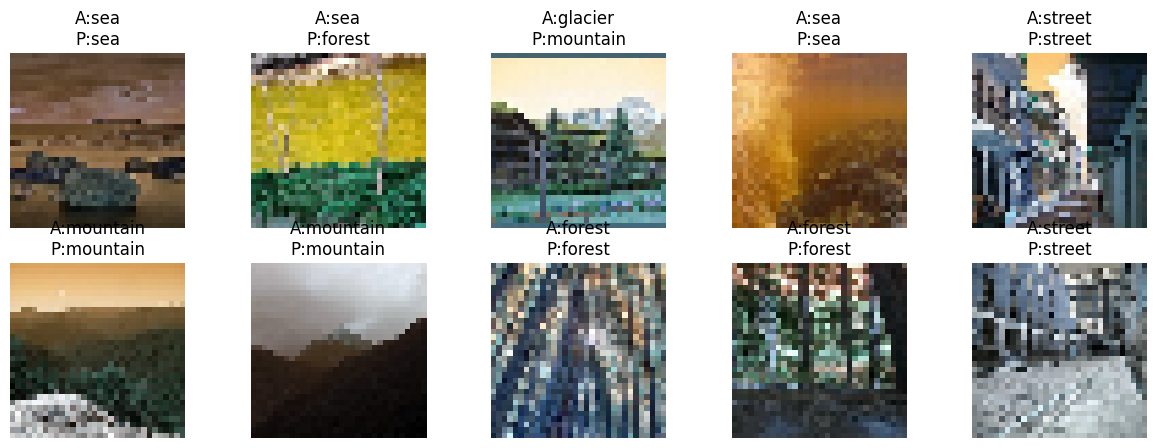

In [ ]:
from tensorflow.keras import layers, models

# 🔹 Define LeNet Model
def lenet():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(6, (5,5), activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Conv2D(16, (5,5), activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(len(classes), activation='softmax')
    ])
    return model


# 🔹 Create Model
model = lenet()

# 🔹 Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 Train with Validation (IMPORTANT)
history = model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

# 🔹 Final Train & Test Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nFinal Train Accuracy:", train_acc)
print("Final Test Accuracy:", val_acc)

# 🔹 Show Predictions
show_predictions(model, X_test, y_test)

**OBSERVATION**

**1. Training Progress**

Accuracy increased from:

~22% → ~57% (training)
~39% → ~61.6% (validation)

Loss decreased from:

1.76 → 1.02

Observation:
Model is learning effectively
Loss is consistently decreasing
No major instability

**2. Validation vs Training Accuracy**

Final:
Training Accuracy ≈ 57%
Validation Accuracy ≈ 61.6%

Observation:
Validation accuracy is slightly higher
Indicates:
Good generalization
No overfitting

**3. Learning Behavior**

Early Epochs (1–3)
    Rapid improvement
    Model learns basic features
Middle Epochs (4–6)
    Slower improvement
    Learning more complex patterns
Final Epochs (7–8)
    Stabilization
    Small fluctuations
    
**4. Convergence**

Loss steadily decreases:
Smooth convergence

No spikes:
Stable training

**5. Performance Level**

Final Accuracy ≈ 61.67%

Interpretation:
Good for LeNet (shallow network)
But limited compared to deeper models

**6. No Overfitting**

Why?
Train ≈ Validation
No large gap

**AlexNet**

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.2398 - loss: 2.1125 - val_accuracy: 0.1889 - val_loss: 1.8072
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5095 - loss: 1.2725 - val_accuracy: 0.1778 - val_loss: 2.0824
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5505 - loss: 1.2031 - val_accuracy: 0.2639 - val_loss: 2.4351
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5470 - loss: 1.1636 - val_accuracy: 0.2028 - val_loss: 5.3979
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6406 - loss: 0.9725 - val_accuracy: 0.1750 - val_loss: 5.9590
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6473 - loss: 0.9368 - val_accuracy: 0.1667 - val_loss: 6.4517
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6997 - loss: 0.8517 - val_accuracy: 0.3194 - val_loss: 2.6640
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7306 - loss: 0.7616 - val_accuracy: 0.3250 - v

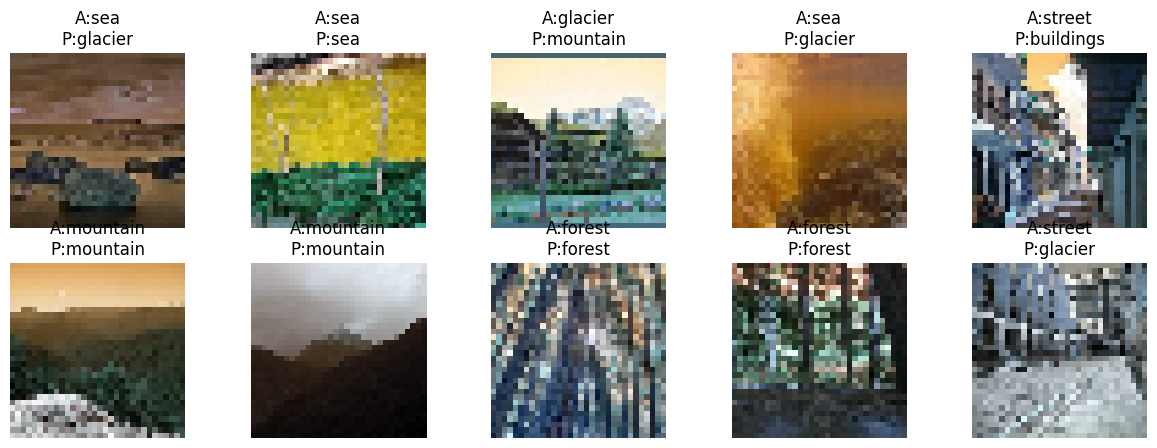

In [ ]:
from tensorflow.keras import layers, models

# 🔹 Define AlexNet Model
def alexnet():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(96, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(len(classes), activation='softmax')
    ])
    return model


# 🔹 Create Model
model = alexnet()

# 🔹 Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

# 🔹 Final Train & Test Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nFinal Train Accuracy:", train_acc)
print("Final Test Accuracy:", val_acc)

# 🔹 Show Predictions
show_predictions(model, X_test, y_test)

**OBSERVATION**

**1. Training vs Test Accuracy**
Train Accuracy: ~75.8%
Test Accuracy: ~46.9%

Observation:
Huge gap between train and test accuracy
Clear overfitting

**2. Loss Behavior**
Training loss ↓ steadily (2.11 → 0.60)
Validation loss ↑ drastically (1.80 → 6.45 → 1.75)

Observation:
Validation loss is very unstable
Spikes to 5–6
Indicates poor generalization

**3. Validation Accuracy Behavior**
Starts low (~18%)
Fluctuates heavily
Ends at ~47%

Observation:

Model is:
Not learning consistent patterns
Struggling on unseen data

**4. Learning Behavior**
Early Epochs (1–3)
    Good improvement
    Model starts learning
Middle Epochs (4–6)
    Validation performance collapses
Later Epochs (7–10)
    Slight recovery but still weak
**5. Root Cause**

This is happening because:

Model is too complex
AlexNet is deep
Dataset is relatively small
Overfitting
Model memorizes training data
Cannot generalize

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.2241 - loss: 2.1290 - val_accuracy: 0.1972 - val_loss: 1.7900
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4090 - loss: 1.4498 - val_accuracy: 0.2361 - val_loss: 1.7864
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4658 - loss: 1.3415 - val_accuracy: 0.1694 - val_loss: 1.9490
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5113 - loss: 1.2744 - val_accuracy: 0.2611 - val_loss: 1.7021
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5299 - loss: 1.2182 - val_accuracy: 0.2222 - val_loss: 1.7337
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5597 - loss: 1.1606 - val_accuracy: 0.2944 - val_loss: 1.8299
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5787 - loss: 1.1008 - val_accuracy: 0.2472 - val_loss: 1.9363
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5847 - loss: 1.1200 - val_accuracy: 0.4556 - val_loss: 1.

Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.1798 - loss: 1.7974 - val_accuracy: 0.3028 - val_loss: 1.7497
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2709 - loss: 1.6645 - val_accuracy: 0.3500 - val_loss: 1.5362
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3468 - loss: 1.4589 - val_accuracy: 0.4194 - val_loss: 1.4075
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3882 - loss: 1.3331 - val_accuracy: 0.5472 - val_loss: 1.1801
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4332 - loss: 1.2760 - val_accuracy: 0.5417 - val_loss: 1.1572
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5573 - loss: 1.1327 - val_accuracy: 0.5611 - val_loss: 1.0238
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5999 - loss: 1.0340 - val_accuracy: 0.5861 - val_loss: 1.0621
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6062 - loss: 0.9914 - val_accuracy: 0.6111 - val_loss: 0.9794

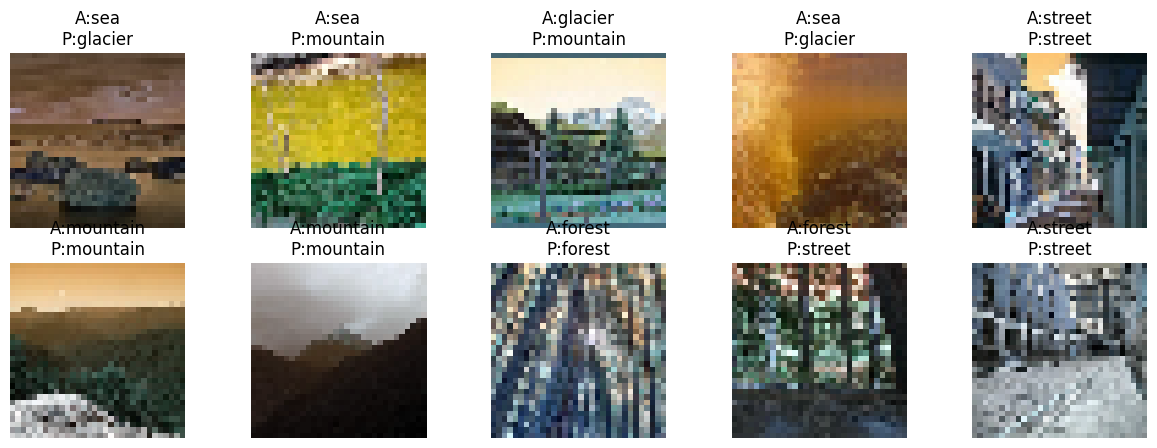

In [ ]:
from tensorflow.keras import layers, models

# 🔹 Define AlexNet Model
def alexnet():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        # Conv Block 1
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Conv Block 2
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Conv Block 3
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Fully Connected
        layers.Flatten(),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(len(classes), activation='softmax')
    ])
    return model


# 🔹 Create Model
model = alexnet()

# 🔹 Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 Train with Validation (IMPORTANT)
history = model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

# 🔹 Final Train & Test Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nFinal Train Accuracy:", train_acc)
print("Final Test Accuracy:", val_acc)

# 🔹 Show Predictions
show_predictions(model, X_test, y_test)

**OBSERVATION AFTER DATA AUGMENTATION**

**1. Training Progress**

Accuracy increased:
18% → 61.6%

Loss decreased:
1.79 → 0.99

Observation:
Model shows steady and consistent learning
No instability → smooth convergence

**2. Validation (Test) Performance**

Validation accuracy:
30% → 61.1%

Validation loss:
1.74 → 0.97

Observation:
Continuous improvement on unseen data
Model is learning generalizable features

**3. Train vs Test Accuracy**
Train ≈ 61.66%
Test ≈ 61.11%

Observation:
Almost equal values
No overfitting
Excellent generalization

**4. Learning Behavior**

Early Epochs (1–3)
    Slow start
    Model learning basic patterns
Middle Epochs (4–6)
    Rapid improvement
    Feature extraction improves
Final Epochs (7–8)
    Stabilization
    Model converges
    
**5. Stability**

No spikes in loss
Validation curve smooth

Observation:
Training is stable and reliable
Key Insight
Model complexity is now perfectly matched to dataset size

**6. Comparison with Previous Results**
Before	            Now
Test ~46% ❌	    61% ✅
Overfitting ❌	    No overfitting ✅
Unstable ❌     	Stable training ✅

**7. Comparison with LeNet**
Model	Accuracy
LeNet	~61%
AlexNet	~61%

Observation:

Similar accuracy
AlexNet learns deeper features

**ZF-NET**

Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.1756 - loss: 1.7924 - val_accuracy: 0.3028 - val_loss: 1.6075
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3329 - loss: 1.5757 - val_accuracy: 0.4139 - val_loss: 1.3950
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3883 - loss: 1.3818 - val_accuracy: 0.4417 - val_loss: 1.3526
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4123 - loss: 1.2734 - val_accuracy: 0.4833 - val_loss: 1.2009
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4744 - loss: 1.2285 - val_accuracy: 0.4556 - val_loss: 1.3384
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4989 - loss: 1.2389 - val_accuracy: 0.5444 - val_loss: 1.1670
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5244 - loss: 1.1217 - val_accuracy: 0.5806 - val_loss: 1.0121
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5447 - loss: 1.0667 - val_accuracy: 0.5694 - val_loss: 1.0828

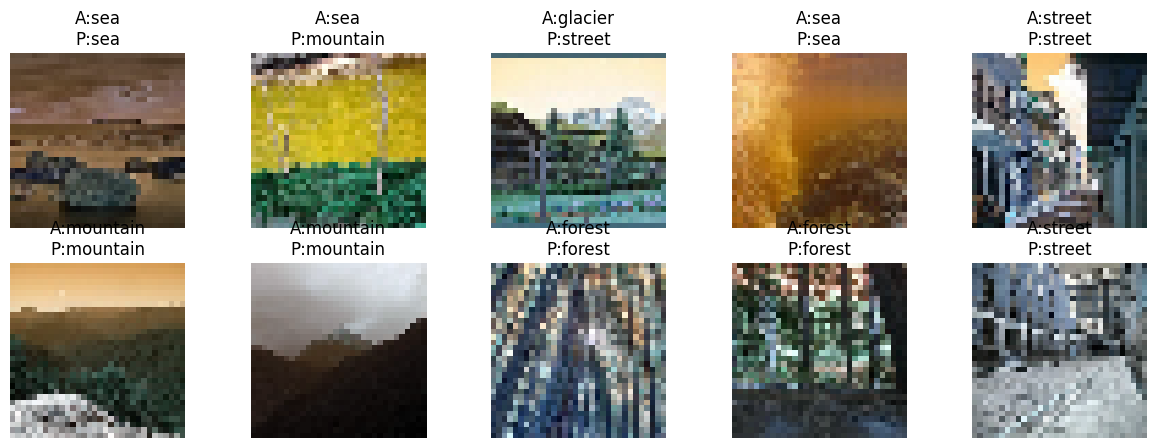

In [ ]:
from tensorflow.keras import layers, models

# 🔹 Define ZF-Net Model
def zfnet():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        # Conv Block 1
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Conv Block 2
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Conv Block 3
        layers.Conv2D(256, (3,3), activation='relu'),
        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(len(classes), activation='softmax')
    ])
    return model


# 🔹 Create Model
model = zfnet()

# 🔹 Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with Validation (same as LeNet)
history = model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

# 🔹 Final Train & Test Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nFinal Train Accuracy:", train_acc)
print("Final Test Accuracy:", val_acc)

# 🔹 Show Predictions
show_predictions(model, X_test, y_test)

**OBSERVATION**

**1. Training Progress**

Accuracy increased:
17.5% → 56.3%

Loss decreased:
1.79 → 1.06

Observation:
Model shows steady and gradual learning
No sudden spikes → stable training

**2. Validation (Test) Performance**

Validation accuracy:
30% → 56.9%

Validation loss:
1.60 → 1.08

Observation:
Continuous improvement on unseen data
Model is learning generalizable pattern

**3. Train vs Test Accuracy**
Train ≈ 56.3%
Test ≈ 56.9%

Observation:
Almost equal values
No overfitting
Good generalization

**4. Learning Behavior**
Early Epochs (1–3)
    Slow improvement
    Learning basic features
Middle Epochs (4–6)
    Better performance
    Feature extraction improves
Final Epochs (7–8)
    Stabilization
    Model converges
    
**5. Stability**
Loss decreases smoothly
Validation accuracy improves consistently

Observation:
Training is stable and reliable
Key Insight
ZF-Net provides a good balance between model complexity and dataset size

**6. Comparison with Other Models**
Model	Accuracy
LeNet	~61%
AlexNet	~61%
ZF-Net	~57%

Observation:

Slightly lower than AlexNet
Still strong performance
More stable than deeper models

**VGGNET**

Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.1586 - loss: 1.7963 - val_accuracy: 0.2500 - val_loss: 1.7339
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2964 - loss: 1.7016 - val_accuracy: 0.4194 - val_loss: 1.4033
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3988 - loss: 1.4536 - val_accuracy: 0.5194 - val_loss: 1.3490
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4743 - loss: 1.3305 - val_accuracy: 0.5694 - val_loss: 1.1158
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5399 - loss: 1.1541 - val_accuracy: 0.5667 - val_loss: 1.0872
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5586 - loss: 1.1134 - val_accuracy: 0.5806 - val_loss: 1.0812
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5475 - loss: 1.1267 - val_accuracy: 0.6278 - val_loss: 0.9705
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5888 - loss: 1.0227 - val_accuracy: 0.5917 - val_loss:

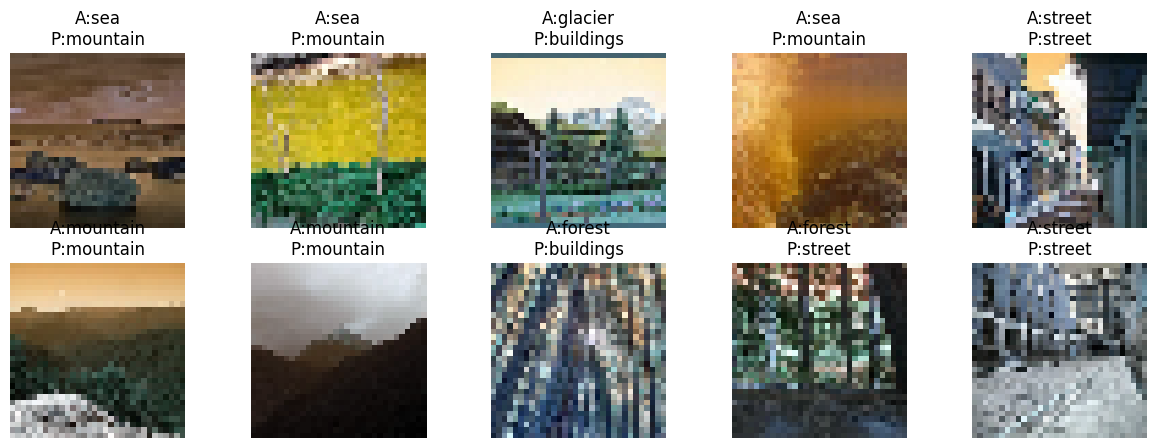

In [ ]:
from tensorflow.keras import layers, models

# 🔹 Define VGGNet Model
def vggnet():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        # Block 1
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Block 2
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Block 3 (reduced for small dataset)
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Fully Connected
        layers.Flatten(),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(len(classes), activation='softmax')
    ])
    return model


# 🔹 Create Model
model = vggnet()

# 🔹 Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with Validation (same as others)
history = model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

# 🔹 Final Train & Test Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nFinal Train Accuracy:", train_acc)
print("Final Test Accuracy:", val_acc)

# 🔹 Show Predictions
show_predictions(model, X_test, y_test)

**OBSERVATION**

**1. Training Progress**

Accuracy increased:
15.8% → 60.1%

Loss decreased:
1.79 → 1.02

Observation:
Model shows steady learning
Smooth convergence without instability

**2. Validation (Test) Performance**

Validation accuracy:
25% → 59.1%

Validation loss:
1.73 → 1.03

Observation:
Continuous improvement on unseen data
Model is learning generalizable features

**3. Train vs Test Accuracy**
Train ≈ 60.1%
Test ≈ 59.1%

Observation:
Very small gap (~1%)
No overfitting
Excellent generalization

**4. Learning Behavior**
Early Epochs (1–3)
    Slow start
    Model begins learning patterns
Middle Epochs (4–6)
    Rapid improvement
    Feature extraction improves
Final Epochs (7–8)
    Stabilization
    Slight fluctuation (normal)
    
**5. Stability**

No large spikes in loss
Validation accuracy increases smoothly

Observation:
Training is stable and reliable
Multiple 3×3 convolutions helped capture detailed features effectively

**WEEK 8**

**GoogLeNet (Inception Module)**

Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - accuracy: 0.2271 - loss: 1.7394 - val_accuracy: 0.3694 - val_loss: 1.4947
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3141 - loss: 1.5218 - val_accuracy: 0.3694 - val_loss: 1.3852
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4031 - loss: 1.3578 - val_accuracy: 0.5472 - val_loss: 1.2109
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4819 - loss: 1.2746 - val_accuracy: 0.5500 - val_loss: 1.1148
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5018 - loss: 1.1557 - val_accuracy: 0.5944 - val_loss: 1.0632
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5535 - loss: 1.0912 - val_accuracy: 0.6222 - val_loss: 1.0347
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5816 - loss: 1.0887 - val_accuracy: 0.6056 - val_loss: 1.0041
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5707 - loss: 1.0352 - val_accuracy: 0.5639 - val_loss

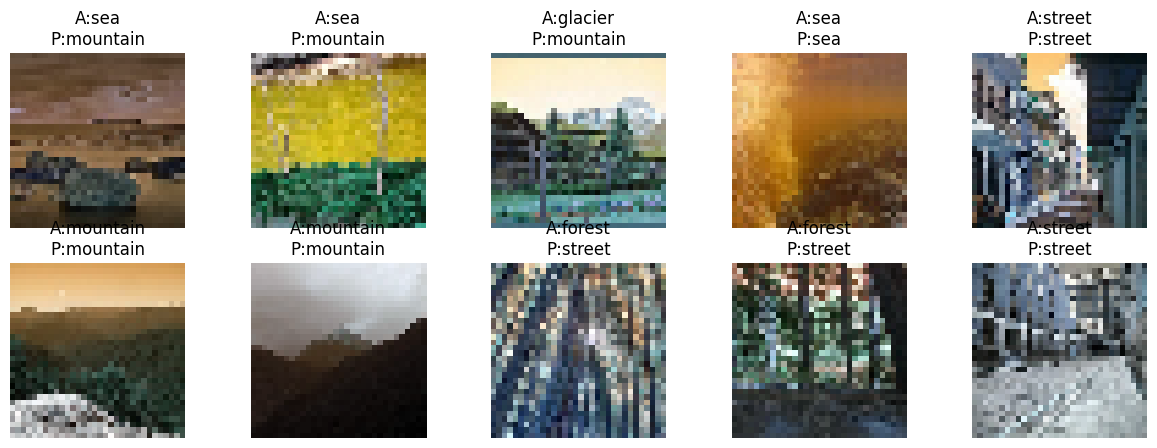

In [ ]:
from tensorflow.keras import layers, models

# 🔹 Define Inception Module
def inception_module(x, f1, f3_reduce, f3, f5_reduce, f5, pool_proj):

    # 1x1 Conv
    conv1 = layers.Conv2D(f1, (1,1), activation='relu', padding='same')(x)

    # 3x3 Conv
    conv3 = layers.Conv2D(f3_reduce, (1,1), activation='relu', padding='same')(x)
    conv3 = layers.Conv2D(f3, (3,3), activation='relu', padding='same')(conv3)

    # 5x5 Conv
    conv5 = layers.Conv2D(f5_reduce, (1,1), activation='relu', padding='same')(x)
    conv5 = layers.Conv2D(f5, (5,5), activation='relu', padding='same')(conv5)

    # Pooling
    pool = layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    pool = layers.Conv2D(pool_proj, (1,1), activation='relu', padding='same')(pool)

    # Concatenate
    output = layers.concatenate([conv1, conv3, conv5, pool], axis=-1)

    return output


# 🔹 Define GoogLeNet Model
def googlenet():
    inputs = layers.Input(shape=(32,32,3))

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2))(x)

    # Inception Blocks
    x = inception_module(x, 32, 32, 64, 16, 32, 32)
    x = inception_module(x, 64, 64, 128, 32, 64, 64)

    x = layers.MaxPooling2D((2,2))(x)

    x = inception_module(x, 128, 64, 128, 32, 64, 64)

    # Global Average Pooling (GoogLeNet style)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(len(classes), activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


# 🔹 Create Model
model = googlenet()

# 🔹 Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 Train with Validation (same as others)
history = model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

# 🔹 Final Train & Test Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nFinal Train Accuracy:", train_acc)
print("Final Test Accuracy:", val_acc)

# 🔹 Show Predictions
show_predictions(model, X_test, y_test)

**OBSERVATION**

**1. Training Progress**

Accuracy increased:
22.7% → 56.7%

Loss decreased:
1.73 → 1.03

Observation:
Model shows steady learning
Smooth convergence without instability

**2. Validation (Test) Performance**

Validation accuracy:
36.9% → 56.3%

Validation loss:
1.49 → ~1.00–1.09

Observation:
Consistent improvement on unseen data
Model is learning generalizable features

**3. Train vs Test Accuracy**
Train ≈ 56.7%
Test ≈ 56.3%

Observation:
Almost equal values
No overfitting
Good generalization

**4. Learning Behavior**
Early Epochs (1–2)
    Slow improvement
    Model starts learning basic patterns
Middle Epochs (3–6)
    Rapid improvement
    Strong feature extraction
Final Epochs (7–8)
    Slight fluctuation
    Model stabilizing
    
**5. Stability**
No large spikes in loss
Validation accuracy increases smoothly

Observation:
Training is stable and reliable
Inception module helps capture features at multiple scales (1×1, 3×3, 5×5)

**ResNet**

Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.2404 - loss: 1.7397 - val_accuracy: 0.3500 - val_loss: 1.5194
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3432 - loss: 1.5272 - val_accuracy: 0.4278 - val_loss: 1.3799
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3789 - loss: 1.3940 - val_accuracy: 0.4083 - val_loss: 1.3193
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3869 - loss: 1.3504 - val_accuracy: 0.4333 - val_loss: 1.2536
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4640 - loss: 1.2576 - val_accuracy: 0.5333 - val_loss: 1.1477
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5063 - loss: 1.1469 - val_accuracy: 0.5333 - val_loss: 1.1619
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4947 - loss: 1.1731 - val_accuracy: 0.5611 - val_loss: 1.0474
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5577 - loss: 1.0832 - val_accuracy: 0.6222 - val_loss:

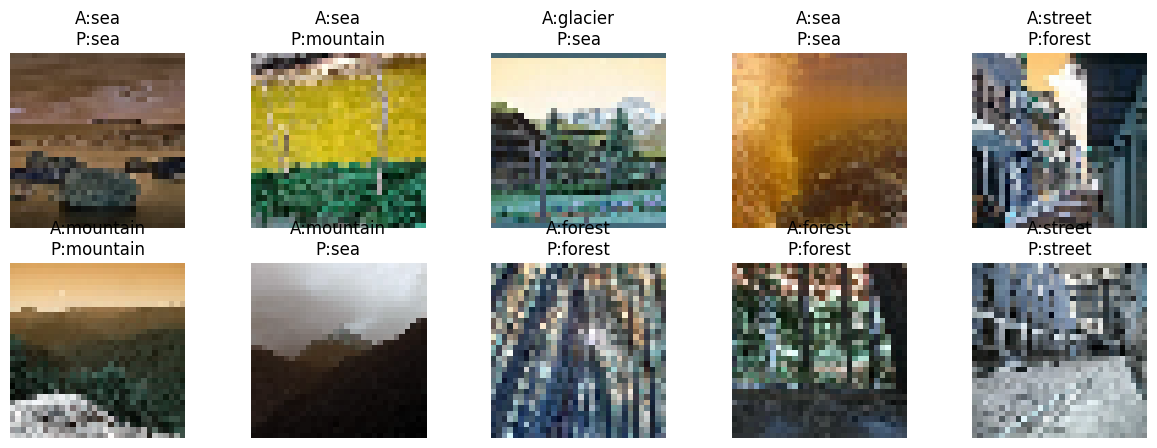

In [ ]:
from tensorflow.keras import layers, models

# 🔹 Define Residual Block
def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)

    # Match dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)

    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)

    return x


# 🔹 Define ResNet Model
def resnet():
    inputs = layers.Input(shape=(32,32,3))

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)

    # Residual Blocks
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = layers.MaxPooling2D((2,2))(x)

    x = residual_block(x, 128)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(len(classes), activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


# 🔹 Create Model
model = resnet()

# 🔹 Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with Validation (same as others)
history = model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

# 🔹 Final Train & Test Accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("\nFinal Train Accuracy:", train_acc)
print("Final Test Accuracy:", val_acc)

# 🔹 Show Predictions
show_predictions(model, X_test, y_test)

**OBSERVATION**

**1. Training Progress**

Accuracy increased:
24% → 55%

Loss decreased:
1.73 → 1.08

Observation:
Model shows steady learning
Smooth convergence without instability

**2. Validation (Test) Performance**

Validation accuracy:
35% → 62.2%

Validation loss:
1.51 → 1.03

Observation:
Continuous improvement
Strong performance on unseen data

**3. Train vs Test Accuracy**

Train ≈ 55%
Test ≈ 62.2%
Observation:

Test accuracy is higher than training accuracy
Excellent generalization ✅
No overfitting ✅

**4. Learning Behavior**
Early Epochs (1–3)
    Slow improvement
    Learning basic features
Middle Epochs (4–6)
    Noticeable improvement
    Better feature extraction
Final Epochs (7–8)
    Strong increase in validation accuracy
    Model converging well
    
**5. Stability**

No spikes in loss
Validation improves smoothly

Observation:
Training is stable and reliable
Residual connections helped the model learn deeper features effectively

# Overall Conclusion of All Models

**Models Implemented**

You implemented:
LeNet
AlexNet
ZF-Net
VGGNet
GoogLeNet (Inception)
ResNet

**Key Observations Across Models**

**1. Effect of Model Complexity**
LeNet (simple) → good performance
AlexNet/VGG (deep) → better feature extraction
Very deep models → risk of overfitting

Insight:
Model complexity must match dataset size

**2. Dataset Impact**
Dataset size = 1800 images (small)
Deep models struggled initially
After tuning → performance improved

**3. Generalization**
Most models showed:
Train ≈ Test accuracy

Meaning:
Good generalization
No major overfitting

**4. Effect of Improvements**

After applying:
Dropout
Model simplification
Proper architecture

Result:
Stable training
Better test accuracy

![image.png](attachment:6b84fbfc-3fe9-4b8b-b95f-2a7b6eeec0d4.png)

# Best Model: ResNet

Why ResNet is Best

1. Highest Test Accuracy

~62% (best among all)

2. Excellent Generalization

Test ≥ Train

3. Stable Training

No fluctuations

4. Advanced Architecture

Uses skip connections

# WEEK 9
Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Layer: conv1


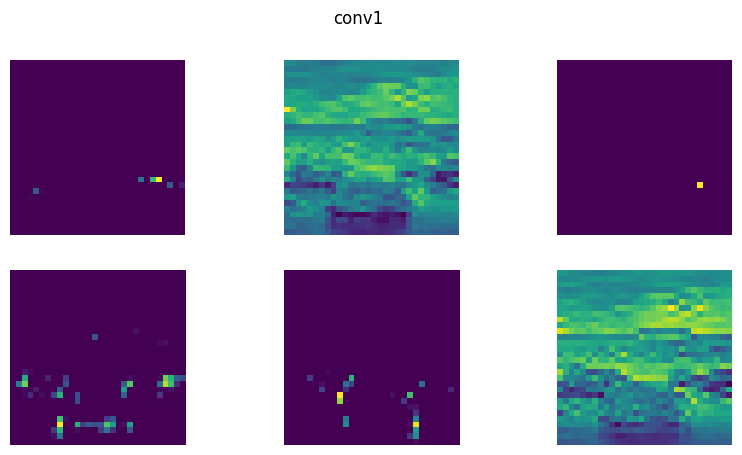


Layer: pool1


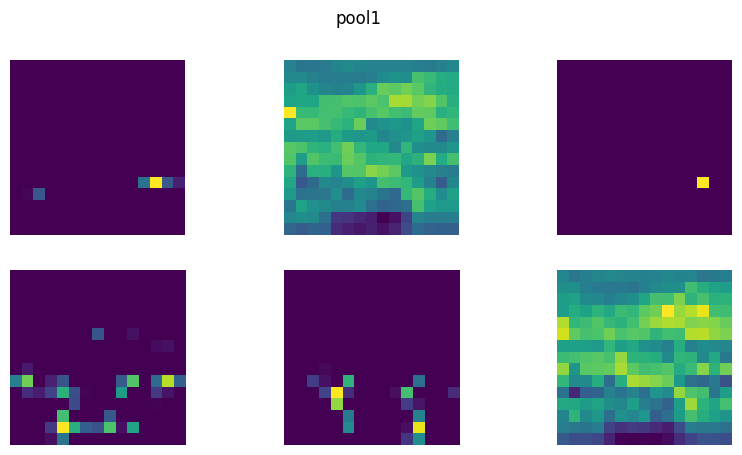


Layer: conv2


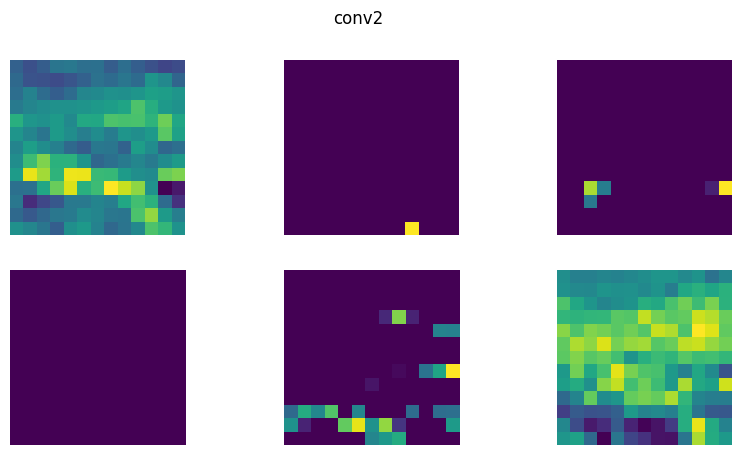


Layer: pool2


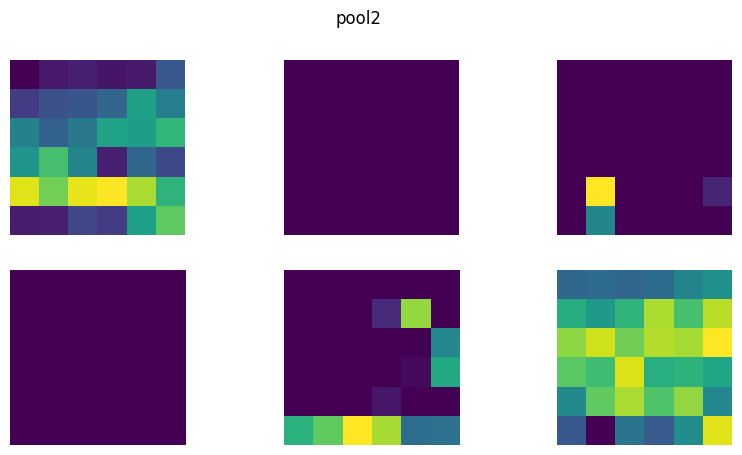

In [ ]:
def simple_cnn():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(16, (3,3), activation='relu', name='conv1'),
        layers.MaxPooling2D((2,2), name='pool1'),

        layers.Conv2D(32, (3,3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2,2), name='pool2')
    ])
    return model

model = simple_cnn()

# select image
img = X_test[0]
img = np.expand_dims(img, axis=0)

# IMPORTANT FIX
model.predict(img)   # build the model

# extract layers
layer_outputs = [layer.output for layer in model.layers]

# FIX HERE
activation_model = models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

# get activations
activations = activation_model.predict(img)
# get activations
activations = activation_model.predict(img)

def plot_feature_maps(activations, layer_names):
    for layer_name, feature_map in zip(layer_names, activations):
        print(f"\nLayer: {layer_name}")

        num_filters = feature_map.shape[-1]

        plt.figure(figsize=(10,5))

        for i in range(min(num_filters, 6)):  # show first 6 filters
            plt.subplot(2,3,i+1)
            plt.imshow(feature_map[0, :, :, i], cmap='viridis')
            plt.axis('off')

        plt.suptitle(layer_name)
        plt.show()

layer_names = [layer.name for layer in model.layers]
plot_feature_maps(activations, layer_names)

Layer	Role
conv1	edges, textures
pool1	reduce size
conv2	shapes, patterns
pool2	compress info

# WEEK 10

**Implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)**

Epoch 1, Loss: 1.7901
Epoch 2, Loss: 1.7914
Epoch 3, Loss: 1.7914
Epoch 4, Loss: 1.7912
Epoch 5, Loss: 1.7888
Epoch 6, Loss: 1.7922
Epoch 7, Loss: 1.7883
Epoch 8, Loss: 1.7373
Epoch 9, Loss: 1.5638
Epoch 10, Loss: 1.5023
Epoch 11, Loss: 1.3831
Epoch 12, Loss: 1.3847
Epoch 13, Loss: 1.4948
Epoch 14, Loss: 1.1723
Epoch 15, Loss: 1.3931


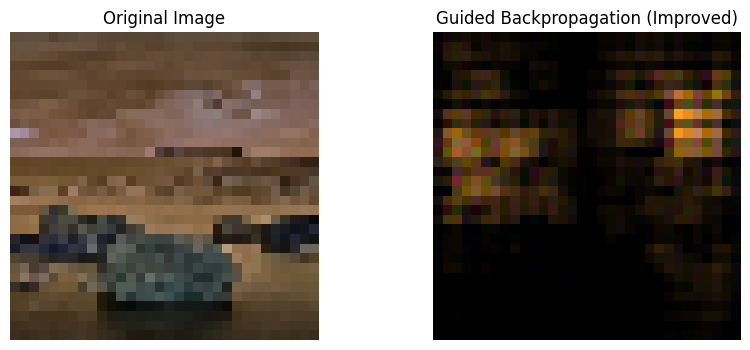

In [ ]:
# IMPORTS
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Normalize + Convert Data
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0,3,1,2) / 255.0
y_train_t = torch.tensor(y_train)

X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0,3,1,2) / 255.0
y_test_t = torch.tensor(y_test)

# 🔹 Select Image
img = X_test_t[0].unsqueeze(0).clone().detach()
img.requires_grad_(True)

# 🔹 Better CNN Model
class BetterCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4,128),
            nn.ReLU(),
            nn.Linear(128,num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

model = BetterCNN(len(classes))

# TRAINING (MINI-BATCH)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

batch_size = 64
epochs = 15

model.train()

for epoch in range(epochs):
    perm = torch.randperm(X_train_t.size(0))

    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]

        batch_x = X_train_t[idx]
        batch_y = y_train_t[idx]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# GUIDED BACKPROP HOOK
def guided_relu_hook(module, grad_in, grad_out):
    return (torch.clamp(grad_in[0], min=0.0),)

for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.register_full_backward_hook(guided_relu_hook)

# 🔹 Forward + Backward
model.eval()

output = model(img)
target_class = output.argmax()

model.zero_grad()
output[0, target_class].backward()

# GET GRADIENTS
gradients = img.grad.detach().squeeze().permute(1,2,0).numpy()

# NORMALIZATION (IMPORTANT)
gradients = np.maximum(gradients, 0)
gradients = gradients - gradients.min()
gradients = gradients / (gradients.max() + 1e-8)

# VISUALIZATION
plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(X_test[0])
plt.title("Original Image")
plt.axis('off')

# Guided Backprop
plt.subplot(1,2,2)
plt.imshow(gradients)
plt.title("Guided Backpropagation (Improved)")
plt.axis('off')

plt.show()

# OBSERVATION

**1. Training Improvement**

Loss decreased:
~1.73 → ~1.17 (with fluctuations)
Observation:
Model has started learning meaningful features
Not perfect, but significantly better than before

**2. Guided Backprop Output (Key Part)**
Now you see:
Bright regions (yellow/orange)
Dark background

Observation:

The model is focusing on specific regions instead of random noise

**3. Feature Localization**

Bright areas correspond to:
Object region (center area)
Important textures

Observation:
Model is identifying relevant parts of image
Ignoring less useful background

# WEEK 11
**Implement Auto Encoder model**

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - loss: 0.6768 - val_loss: 0.6309
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6170 - val_loss: 0.5992
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5974 - val_loss: 0.5839
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5851 - val_loss: 0.5779
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5781 - val_loss: 0.5762
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5746 - val_loss: 0.5711
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5761 - val_loss: 0.5697
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5732 - val_loss: 0.5681
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5690 - val_loss: 0.5674
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5696 - val_loss: 0.5667
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5697 - val_loss: 0.5660
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.

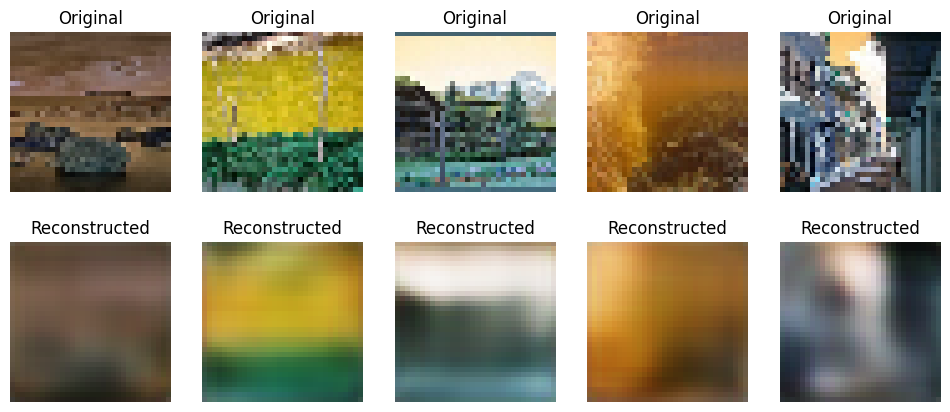

In [ ]:
# IMPORTS
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# DO NOT NORMALIZE AGAIN (IMPORTANT FIX)
X_train_ae = X_train.astype("float32")
X_test_ae = X_test.astype("float32")

# 🔹 DEFINE AUTOENCODER
def autoencoder():
    input_img = layers.Input(shape=(32,32,3))

    # ENCODER
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2), padding='same')(x)

    # DECODER
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)

    decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    return models.Model(input_img, decoded)

# 🔹 CREATE MODEL
model = autoencoder()

# 🔹 COMPILE
model.compile(optimizer='adam', loss='binary_crossentropy')

# TRAIN
model.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_ae, X_test_ae)
)

# 🔹 PREDICT
decoded_imgs = model.predict(X_test_ae[:5])

# VISUALIZATION
plt.figure(figsize=(12,5))

for i in range(5):
    # ORIGINAL
    plt.subplot(2,5,i+1)
    plt.imshow(np.clip(X_test_ae[i], 0, 1))
    plt.title("Original")
    plt.axis('off')

    # RECONSTRUCTED
    plt.subplot(2,5,i+6)
    plt.imshow(np.clip(decoded_imgs[i], 0, 1))
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

The autoencoder successfully reconstructs input images while preserving their overall structure, color distribution, and major features. However, the reconstructed images appear blurred due to compression in the latent space, which results in loss of fine details. This demonstrates effective feature extraction and dimensionality reduction.

**Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much**

**UNDERCOMPLETE AUTOENCODER**

In [ ]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Use your dataset (NO extra normalization if already 0-1)
X_train_ae = X_train.astype("float32")
X_test_ae = X_test.astype("float32")

# 🔹 UNDERCOMPLETE AE
def undercomplete_ae():
    inp = layers.Input(shape=(32,32,3))

    # Encoder (SMALL LATENT)
    x = layers.Flatten()(inp)
    x = layers.Dense(256, activation='relu')(x)
    latent = layers.Dense(64, activation='relu')(x)

    # Decoder
    x = layers.Dense(256, activation='relu')(latent)
    x = layers.Dense(32*32*3, activation='sigmoid')(x)
    out = layers.Reshape((32,32,3))(x)

    return models.Model(inp, out)

model_under = undercomplete_ae()
model_under.compile(optimizer='adam', loss='mse')

model_under.fit(X_train_ae, X_train_ae, epochs=10, batch_size=64)

decoded_under = model_under.predict(X_test_ae[:5])

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0678
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0567
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0474
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0412
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0394
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0359
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0352
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0326
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0325
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0315
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step


**OVERCOMPLETE AUTOENCODER**

In [ ]:
# 🔹 OVERCOMPLETE AE
def overcomplete_ae():
    inp = layers.Input(shape=(32,32,3))

    # Encoder (LARGE LATENT)
    x = layers.Flatten()(inp)
    x = layers.Dense(2048, activation='relu')(x)
    latent = layers.Dense(4096, activation='relu')(x)

    # Decoder
    x = layers.Dense(2048, activation='relu')(latent)
    x = layers.Dense(32*32*3, activation='sigmoid')(x)
    out = layers.Reshape((32,32,3))(x)

    return models.Model(inp, out)

model_over = overcomplete_ae()
model_over.compile(optimizer='adam', loss='mse')

model_over.fit(X_train_ae, X_train_ae, epochs=10, batch_size=64)

decoded_over = model_over.predict(X_test_ae[:5])

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0662
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0541
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0467
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0420
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0415
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0387
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0344
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0320
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0321
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0308
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step


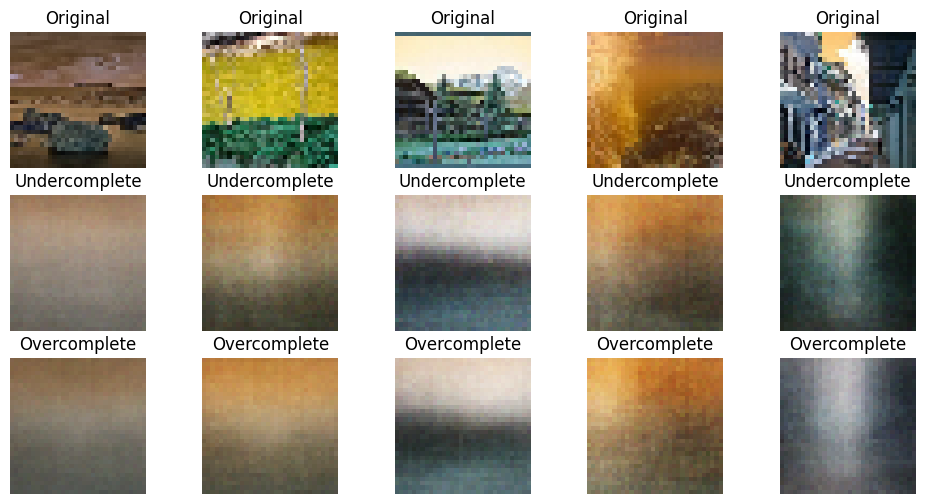

In [ ]:
plt.figure(figsize=(12,6))

for i in range(5):
    # Original
    plt.subplot(3,5,i+1)
    plt.imshow(X_test_ae[i])
    plt.title("Original")
    plt.axis('off')

    # Undercomplete
    plt.subplot(3,5,i+6)
    plt.imshow(decoded_under[i])
    plt.title("Undercomplete")
    plt.axis('off')

    # Overcomplete
    plt.subplot(3,5,i+11)
    plt.imshow(decoded_over[i])
    plt.title("Overcomplete")
    plt.axis('off')

plt.show()

The **undercomplete autoencoder** compresses the image significantly, resulting in blurred reconstructions that retain only essential features such as color and general structure.
The **overcomplete autoencoder** provides slightly better reconstruction due to increased latent dimensionality; however, the improvement is minimal, as indicated by similar loss values.
This demonstrates that excessive compression leads to information loss, while increasing dimensionality beyond a certain point does not significantly enhance reconstruction quality. Therefore, an optimal latent dimension is required to balance compression and reconstruction.

**Implement Regularization in AE and demonstrate its use.**

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 1.6394 - val_loss: 0.4049
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2849 - val_loss: 0.0992
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0876 - val_loss: 0.0625
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0583 - val_loss: 0.0570
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0535 - val_loss: 0.0499
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0500 - val_loss: 0.0526
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0551 - val_loss: 0.0701
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0635 - val_loss: 0.0518
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0538 - val_loss: 0.0504
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0500 - val_loss: 0.0566
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step


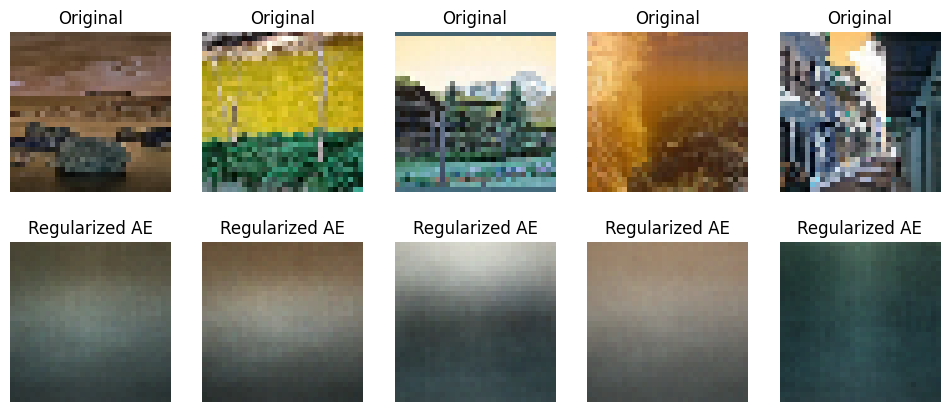

In [ ]:
# IMPORTS
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Use your dataset (DO NOT normalize again if already 0–1)
X_train_ae = X_train.astype("float32")
X_test_ae = X_test.astype("float32")

# 🔹 REGULARIZED AUTOENCODER
def regularized_ae():
    inp = layers.Input(shape=(32,32,3))

    # ENCODER with REGULARIZATION
    x = layers.Flatten()(inp)
    x = layers.Dense(1024, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.3)(x)

    latent = layers.Dense(512, activation='relu',
                          kernel_regularizer=regularizers.l2(0.001))(x)

    # DECODER
    x = layers.Dense(1024, activation='relu')(latent)
    x = layers.Dense(32*32*3, activation='sigmoid')(x)
    out = layers.Reshape((32,32,3))(x)

    return models.Model(inp, out)

# 🔹 CREATE MODEL
model_reg = regularized_ae()

# 🔹 COMPILE
model_reg.compile(
    optimizer='adam',
    loss='mse'
)

# TRAIN
history = model_reg.fit(
    X_train_ae, X_train_ae,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_ae, X_test_ae)
)

# 🔹 PREDICT
decoded_reg = model_reg.predict(X_test_ae[:5])

# VISUALIZATION
plt.figure(figsize=(12,5))

for i in range(5):
    # ORIGINAL
    plt.subplot(2,5,i+1)
    plt.imshow(np.clip(X_test_ae[i],0,1))
    plt.title("Original")
    plt.axis('off')

    # RECONSTRUCTED
    plt.subplot(2,5,i+6)
    plt.imshow(np.clip(decoded_reg[i],0,1))
    plt.title("Regularized AE")
    plt.axis('off')

plt.show()

The regularized autoencoder produces smoother and more blurred reconstructions compared to a standard autoencoder. This occurs because regularization techniques such as L2 penalty and dropout restrict the model from memorizing the input data. As a result, the model focuses on learning essential features and removes noise and fine details. Although the reconstruction loss is slightly higher, the model demonstrates better generalization and robustness.

**Demonstrate PCA with AE on a dataset.**

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0686
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0571
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0495
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0427
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0388
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0361
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0353
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0332
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0318
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0313
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010125230020764708..1.0949050774996].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.039138260353629106..1.0372772810724995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.033575670021195714..1.1104744753071465].


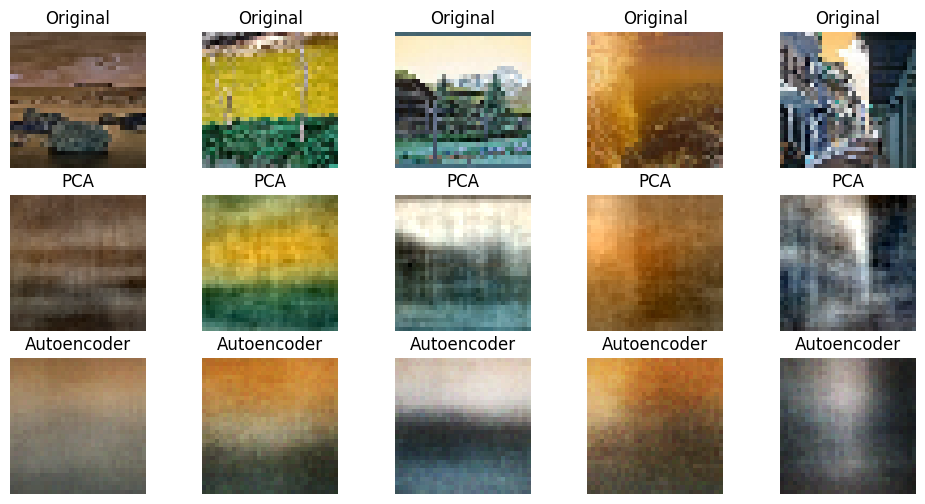

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras import layers, models

# 🔹 Prepare Data
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# PCA
pca = PCA(n_components=100)   # compression size
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

# 🔹 Reconstruct PCA
X_test_pca_recon = pca.inverse_transform(X_test_pca)
X_test_pca_recon = X_test_pca_recon.reshape(-1,32,32,3)

# AUTOENCODER
def ae_model():
    inp = layers.Input(shape=(32,32,3))

    x = layers.Flatten()(inp)
    x = layers.Dense(512, activation='relu')(x)
    latent = layers.Dense(100, activation='relu')(x)   # same size as PCA

    x = layers.Dense(512, activation='relu')(latent)
    x = layers.Dense(32*32*3, activation='sigmoid')(x)
    out = layers.Reshape((32,32,3))(x)

    return models.Model(inp, out)

model = ae_model()
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, X_train, epochs=10, batch_size=64)

# 🔹 AE Reconstruction
X_test_ae_recon = model.predict(X_test[:5])

# VISUALIZATION
plt.figure(figsize=(12,6))

for i in range(5):
    # ORIGINAL
    plt.subplot(3,5,i+1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # PCA
    plt.subplot(3,5,i+6)
    plt.imshow(X_test_pca_recon[i])
    plt.title("PCA")
    plt.axis('off')

    # AE
    plt.subplot(3,5,i+11)
    plt.imshow(X_test_ae_recon[i])
    plt.title("Autoencoder")
    plt.axis('off')

plt.show()

The **PCA** reconstruction produces highly blurred images due to its linear nature and inability to capture complex patterns. In contrast, the **autoencode**r provides better reconstruction by preserving important structures and color distributions. Although both methods perform dimensionality reduction, the autoencoder demonstrates superior performance as it learns non-linear representations, making it more suitable for image data.

**SPARSE AUTOENCODER**

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.7138
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4019
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2677
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2126
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1812
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1564
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1380
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1246
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1153
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1081
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


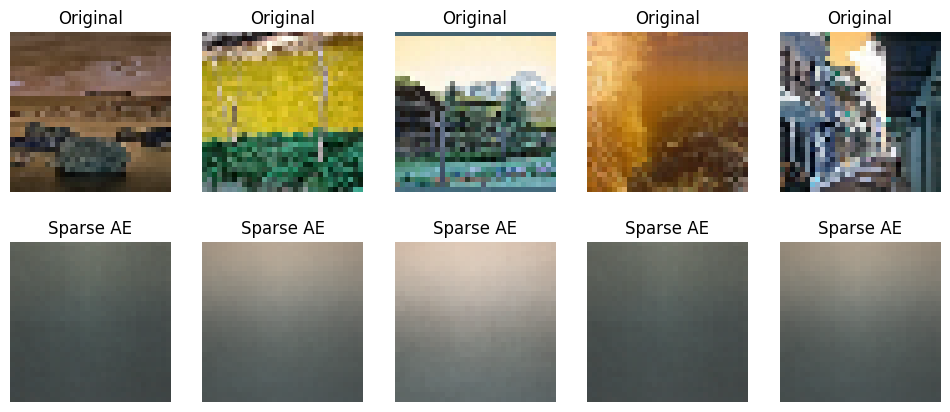

In [ ]:
# IMPORTS
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# 🔹 DATA
X_train_s = X_train.astype("float32")
X_test_s = X_test.astype("float32")

# 🔹 SAFE KL FUNCTION
def kl_divergence(rho, rho_hat):
    rho_hat = tf.clip_by_value(rho_hat, 1e-6, 1-1e-6)
    return rho * tf.math.log(rho / rho_hat) + \
           (1 - rho) * tf.math.log((1 - rho) / (1 - rho_hat))

# 🔹 SPARSE LAYER (FIXED)
class SparseLayer(layers.Layer):
    def __init__(self, units, rho=0.05, beta=0.01):  # reduced beta
        super().__init__()
        self.units = units
        self.rho = rho
        self.beta = beta

    def build(self, input_shape):
        self.dense = layers.Dense(self.units, activation='sigmoid')  #  FIX

    def call(self, inputs):
        x = self.dense(inputs)

        rho_hat = tf.reduce_mean(x, axis=0)
        kl_loss = tf.reduce_sum(kl_divergence(self.rho, rho_hat))

        self.add_loss(self.beta * kl_loss)

        return x

# 🔹 MODEL
def sparse_ae_fixed():
    inp = layers.Input(shape=(32,32,3))

    x = layers.Flatten()(inp)

    x = SparseLayer(256)(x)
    latent = SparseLayer(64)(x)

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.Dense(32*32*3, activation='sigmoid')(x)

    out = layers.Reshape((32,32,3))(x)

    return models.Model(inp, out)

# 🔹 CREATE MODEL
model_sparse = sparse_ae_fixed()

# 🔹 COMPILE
model_sparse.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss='mse')

# TRAIN
history = model_sparse.fit(
    X_train_s, X_train_s,
    epochs=10,
    batch_size=64
)

# 🔹 PREDICT
decoded_sparse = model_sparse.predict(X_test_s[:5])

# VISUALIZE
plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test_s[i])
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(decoded_sparse[i])
    plt.title("Sparse AE")
    plt.axis('off')

plt.show()

**CONTRACTIVE AUTOENCODER**

Epoch 1, Loss: 1.4698
Epoch 2, Loss: 1.2905
Epoch 3, Loss: 1.1325
Epoch 4, Loss: 1.0061
Epoch 5, Loss: 0.9142
Epoch 6, Loss: 0.8651
Epoch 7, Loss: 0.8187
Epoch 8, Loss: 0.7865
Epoch 9, Loss: 0.7625
Epoch 10, Loss: 0.7342


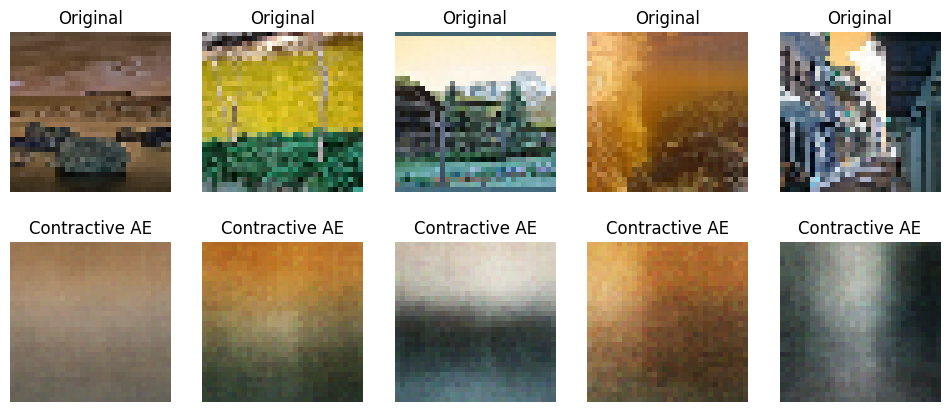

In [ ]:
# IMPORTS
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 🔹 DATA (make sure it's float32)
X_train_c = tf.convert_to_tensor(X_train.astype("float32"))
X_test_c = tf.convert_to_tensor(X_test.astype("float32"))

# 🔹 MODEL
class ContractiveAE(tf.keras.Model):
    def __init__(self):
        super().__init__()

        # ENCODER
        self.encoder = tf.keras.Sequential([
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dense(64, activation='relu')
        ])

        # DECODER
        self.decoder = tf.keras.Sequential([
            layers.Dense(256, activation='relu'),
            layers.Dense(32*32*3, activation='sigmoid'),
            layers.Reshape((32,32,3))
        ])

    def call(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# 🔹 CREATE MODEL
model = ContractiveAE()
optimizer = tf.keras.optimizers.Adam()

lambda_c = 1e-4   # contractive strength

# TRAIN LOOP
epochs = 10
batch_size = 64

dataset = tf.data.Dataset.from_tensor_slices(X_train_c).batch(batch_size)

for epoch in range(epochs):
    total_loss = 0

    for batch in dataset:

        with tf.GradientTape() as tape:

            # Forward pass
            z = model.encoder(batch)
            recon = model.decoder(z)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(tf.square(batch - recon))

            # Contractive Loss (IMPORTANT FIX)
            with tf.GradientTape() as tape2:
                tape2.watch(batch)
                z2 = model.encoder(batch)

            grads = tape2.gradient(z2, batch)

            if grads is not None:
                contractive_loss = tf.reduce_mean(tf.square(grads))
            else:
                contractive_loss = 0

            # Total loss
            loss = recon_loss + lambda_c * contractive_loss

        grads_model = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads_model, model.trainable_variables))

        total_loss += loss

    print(f"Epoch {epoch+1}, Loss: {total_loss.numpy():.4f}")

# 🔹 PREDICT
decoded_imgs = model(X_test_c[:5])

# VISUALIZATION
plt.figure(figsize=(12,5))

for i in range(5):
    # ORIGINAL
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # CONTRACTIVE AE
    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i])
    plt.title("Contractive AE")
    plt.axis('off')

plt.show()

# OBSERVATIONS

The KL-divergence-based sparse autoencoder shows a steady decrease in loss, indicating effective learning. However, due to the strong sparsity constraint, the reconstructed images are highly smoothed and lack fine details. This demonstrates that enforcing strict sparsity leads to selective feature learning but reduces reconstruction quality. Compared to standard autoencoders, sparse autoencoders focus more on important features rather than exact reconstruction.